In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [32]:
df = pd.read_csv("cetes_28d_mensual.csv")
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d/%m/%y")
df["Tasa_CETES_28d"] = df["Tasa_CETES_28d"] / 100
df = df[df["Fecha"].dt.year >= 2000]

In [63]:
print(df.head())
print(df.tail())

         Fecha  Tasa_CETES_28d     r_t    r_t1
191 2000-02-01          0.1581  0.1619  0.1581
192 2000-03-01          0.1366  0.1581  0.1366
193 2000-04-01          0.1293  0.1366  0.1293
194 2000-05-01          0.1418  0.1293  0.1418
195 2000-06-01          0.1565  0.1418  0.1565
         Fecha  Tasa_CETES_28d     r_t    r_t1
501 2025-12-01          0.0716  0.0719  0.0716
502 2026-01-01          0.0700  0.0716  0.0700
503 2026-02-01          0.0686  0.0700  0.0686
504 2026-03-01          0.0681  0.0686  0.0681
505 2026-04-01          0.0658  0.0681  0.0658
315


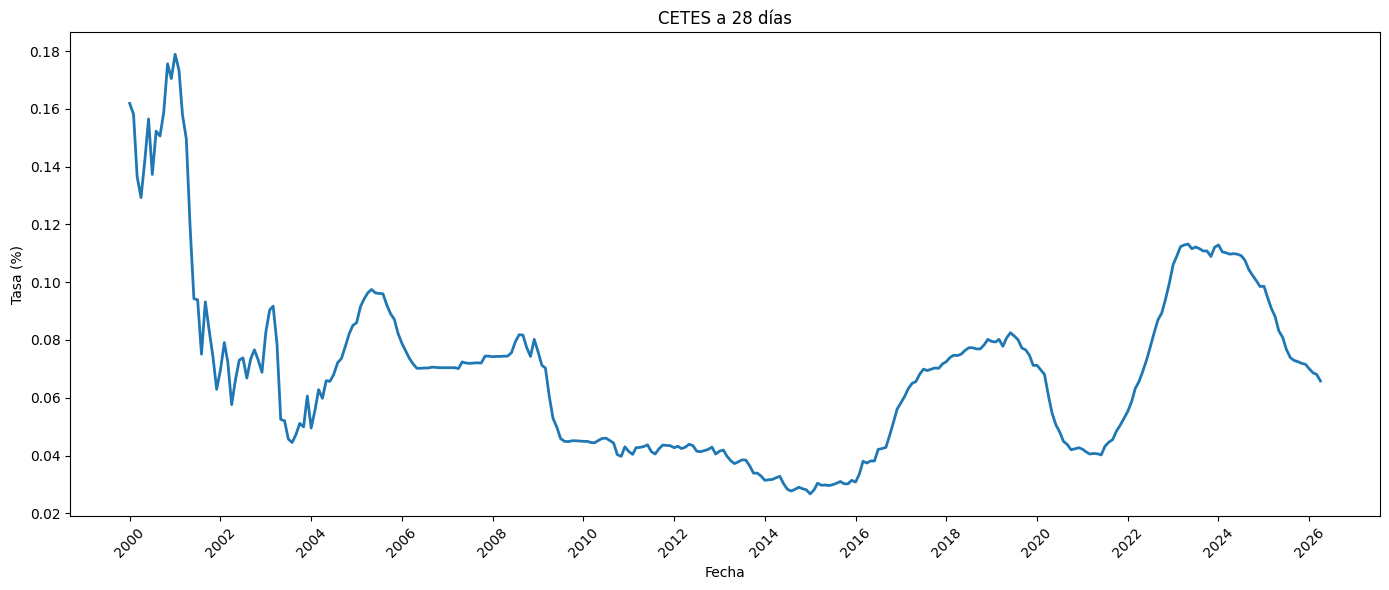

In [34]:
plt.figure(figsize=(14,6))
plt.plot(df["Fecha"], df["Tasa_CETES_28d"], linewidth=2)
plt.title("CETES a 28 días")
plt.xlabel("Fecha")
plt.ylabel("Tasa (%)")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

In [35]:
media = df["Tasa_CETES_28d"].mean()
volatilidad = df["Tasa_CETES_28d"].std()
print("Media:", media)
print("Volatilidad:", volatilidad)

Media: 0.06906044303797468
Volatilidad: 0.030198382987193042


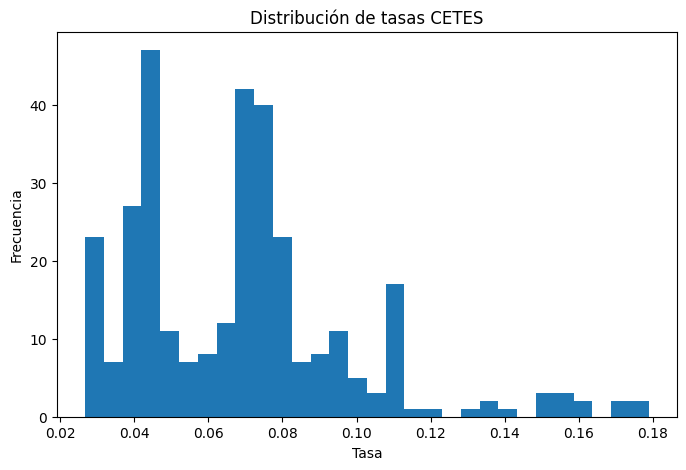

In [36]:
plt.figure(figsize=(8,5))
plt.hist(df["Tasa_CETES_28d"], bins=30)
plt.title("Distribución de tasas CETES")
plt.xlabel("Tasa")
plt.ylabel("Frecuencia")
plt.show()

In [37]:
df["r_t"] = df["Tasa_CETES_28d"].shift(1)
df["r_t1"] = df["Tasa_CETES_28d"]
df = df.dropna()

In [56]:
from sklearn.linear_model import LinearRegression
X = df[["r_t"]]
y = df["r_t1"]

modelo = LinearRegression()
modelo.fit(X, y)

u = modelo.intercept_
v = modelo.coef_[0]


In [61]:
dt = 1/12
a = -np.log(v)/dt
b = u / (1 - v)
residuos = y - modelo.predict(X)
sigma_e = np.std(residuos)
sigma = sigma_e * np.sqrt(
    (2 * a) / (1 - np.exp(-2 * a * dt))
)


In [62]:
print("a =", a)
print("b =", b)
print("sigma =", sigma)

a = 0.3607263038113963
b = 0.05876865295894599
sigma = 0.017858449160349656


In [45]:
dt = 1/12
N = len(df)
r0 = df["Tasa_CETES_28d"].iloc[0]

In [67]:
tasas_sim = np.zeros(N)
tasas_sim[0] = r0

for t in range(1, N):

    media = (
        b
        + (tasas_sim[t-1] - b)
        * np.exp(-a * dt)
    )

    varianza = (
        sigma**2 / (2*a)
        * (1 - np.exp(-2*a*dt))
    )

    tasas_sim[t] = np.random.normal(
        media,
        np.sqrt(varianza)
    )

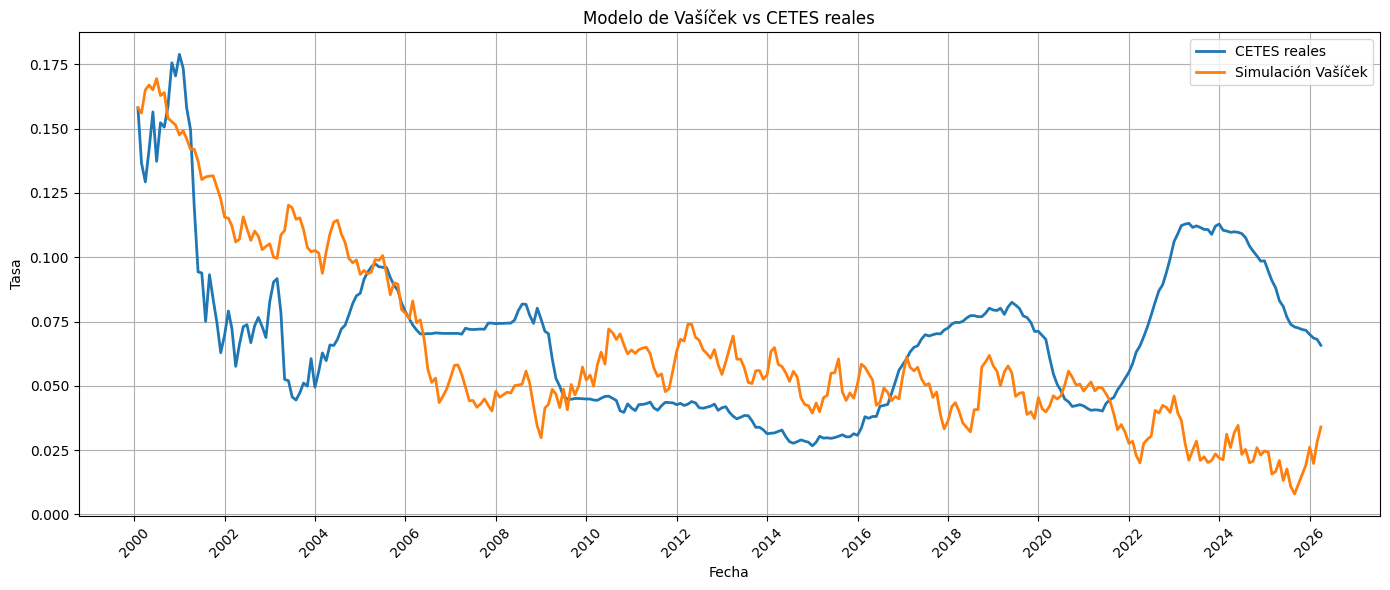

In [47]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Fecha"],
    df["Tasa_CETES_28d"],
    label="CETES reales",
    linewidth=2
)

plt.plot(
    df["Fecha"],
    tasas_sim,
    label="Simulación Vašíček",
    linewidth=2
)

plt.title("Modelo de Vašíček vs CETES reales")

plt.xlabel("Fecha")
plt.ylabel("Tasa")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

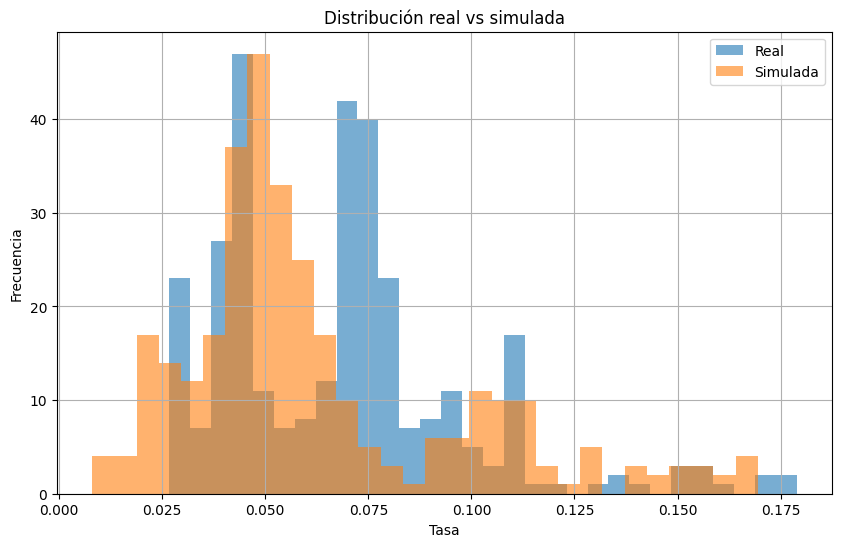

In [48]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Tasa_CETES_28d"],
    bins=30,
    alpha=0.6,
    label="Real"
)

plt.hist(
    tasas_sim,
    bins=30,
    alpha=0.6,
    label="Simulada"
)

plt.title("Distribución real vs simulada")

plt.xlabel("Tasa")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(True)

plt.show()

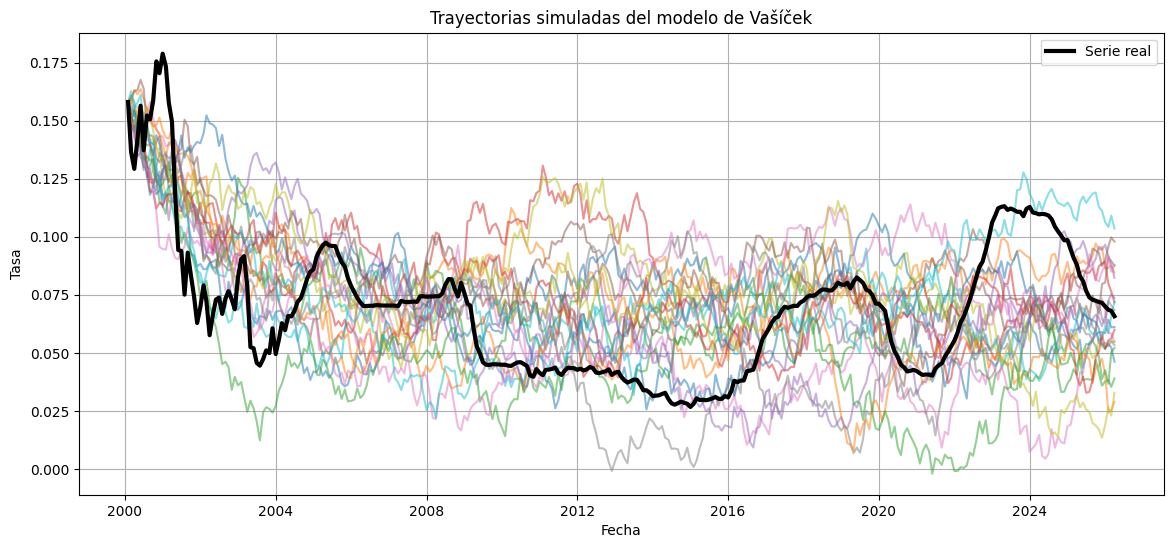

In [49]:
plt.figure(figsize=(14,6))

for i in range(20):

    r = np.zeros(N)
    r[0] = r0

    for t in range(1, N):

        media = (
            b
            + (r[t-1] - b)
            * np.exp(-a * dt)
        )

        varianza = (
            sigma**2 / (2*a)
            * (1 - np.exp(-2*a*dt))
        )

        r[t] = np.random.normal(
            media,
            np.sqrt(varianza)
        )

    plt.plot(df["Fecha"], r, alpha=0.5)

plt.plot(
    df["Fecha"],
    df["Tasa_CETES_28d"],
    color="black",
    linewidth=3,
    label="Serie real"
)

plt.title("Trayectorias simuladas del modelo de Vašíček")

plt.xlabel("Fecha")
plt.ylabel("Tasa")

plt.legend()

plt.grid(True)

plt.show()

In [50]:
print("Media real:")
print(df["Tasa_CETES_28d"].mean())

print("Media simulada:")
print(np.mean(tasas_sim))

Media real:
0.06876571428571429
Media simulada:
0.06258645403589219


In [51]:
print("Volatilidad real:")
print(df["Tasa_CETES_28d"].std())

print("Volatilidad simulada:")
print(np.std(tasas_sim))

Volatilidad real:
0.029787746471568028
Volatilidad simulada:
0.034425396733586265


In [52]:
n_sim = 20
simulaciones = np.zeros((N, n_sim))

for j in range(n_sim):

    r = np.zeros(N)

    r[0] = r0

    for t in range(1, N):

        media = (
            b
            + (r[t-1] - b)
            * np.exp(-a * dt)
        )

        varianza = (
            sigma**2 / (2*a)
            * (1 - np.exp(-2*a*dt))
        )

        r[t] = np.random.normal(
            media,
            np.sqrt(varianza)
        )

    simulaciones[:, j] = r

In [53]:
promedio_simulado = np.mean(simulaciones, axis=1)
serie_real = df["Tasa_CETES_28d"].values

In [54]:
ecm = np.mean(
    (serie_real - promedio_simulado)**2
)

print("Error Cuadrático Medio:", ecm)

Error Cuadrático Medio: 0.0006261890727569329


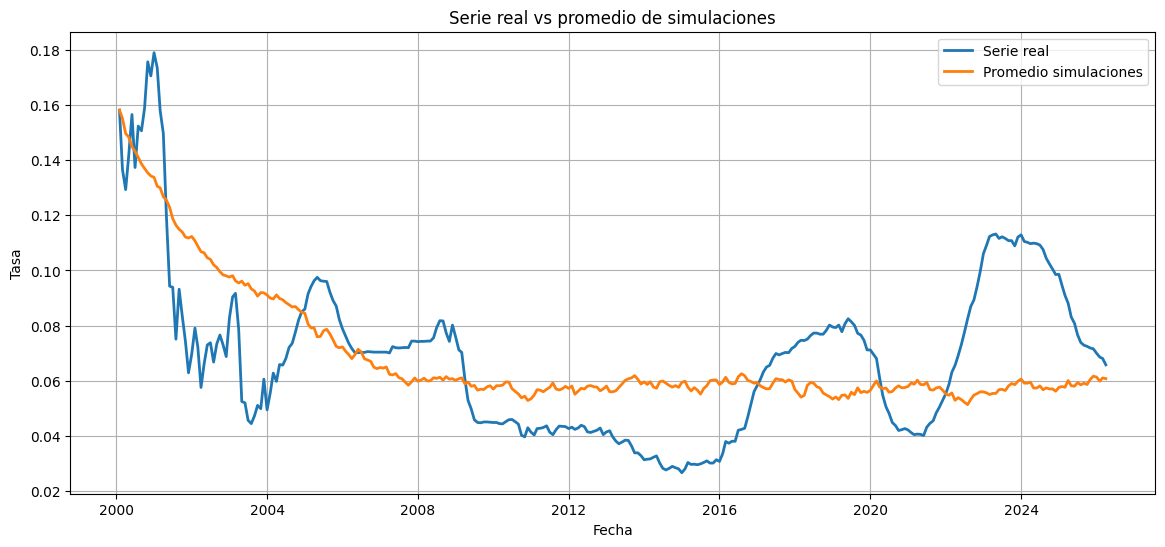

In [55]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Fecha"],
    serie_real,
    label="Serie real",
    linewidth=2
)

plt.plot(
    df["Fecha"],
    promedio_simulado,
    label="Promedio simulaciones",
    linewidth=2
)

plt.title("Serie real vs promedio de simulaciones")

plt.xlabel("Fecha")
plt.ylabel("Tasa")

plt.legend()

plt.grid(True)

plt.show()